 ### Differential abundance test

This notebook implements the **differential abundance** and **fitness loss** analyses for the whole brain in vivo CRISPR screen. It produces results and figures for **Figure 2 A, B, C**, **Figure S5 A, B, C** and Data S3 of the manuscript.

## Summary of analyses

1. **Fisher's exact test (differential abundance)**  
   For each perturbation and cell type (neighborhood), tests whether the observed single-cell proportion differs from the expected proportion based on AAV/NGS library composition (Data S3). Uses a 2×2 table: perturbation vs control, expected (from NGS) vs observed (from scRNA-seq). Performed at guide level and aggregated to gene level with FDR (Benjamini–Hochberg).

2. **Gene-level significance**  
   Identifies (gene, cell type) pairs with significant depletion (adj. *P* &lt; 0.05, odds ratio &gt; 1.2) and requiring ≥2 supporting guides; excludes Safe_target.

3. **MAGeCK2 test**  
   For each cell type, builds a count table (observed vs expected from NGS) from the Fisher table and runs `mageck2 test` (RRA) to rank genes by depletion/enrichment. Inputs are written under `analysis/.../mageck/<cell_type_col>/mageck_input/`; the actual MAGeCK run is done via `scripts/run_mageck.sh` (or equivalent).

4. **Figures**  
   - Number of depleted guides per condition and odds-ratio distributions  
   - Fitness loss / log-odds heatmaps  for significant conditions  
   - Guide-level consistency for selected conditions  

## Data and paths

- **Data:** `WB8588_screen_gex_filtered.zarr` (processed single-cell); NGS/AAV counts from `aav_sequence_counts.csv`.  

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'sans-serif'

In [3]:
import os
import numpy as np
import polars as pl
import pandas as pd
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

import seaborn as sns

%matplotlib inline
%config InlineBackend.close_figures = False
import matplotlib.pyplot as plt

In [4]:
BASE_DIR = "/data/wholebrain_crispr_atlas"
FIG_DIR = "Figures"
DATA_DIR = f"{BASE_DIR}/analysis/cell_type_proportions"
METADATA_PATH = f"{BASE_DIR}/metadata/all_obs.parquet"

In [5]:
os.makedirs(FIG_DIR, exist_ok=True)

In [6]:
cell_type_col = "neighborhood"

In [18]:
all_obs = pl.read_parquet(METADATA_PATH)
all_obs = all_obs.filter(
    (pl.col("num_guides") == 1) & 
    (pl.col("log_ambient_mse_norm") > 0.09) & 
    (pl.col("scDblFinder.class") == "singlet") & 
    (pl.col("num_genes") >= 2000) & 
    ~(pl.col("cluster").is_in(["1", "2", "3", "6", "17", "57", "83", "NA"]))
)

all_obs = all_obs.to_pandas()

all_obs.rename(columns={"guide_call": "target_guide"}, inplace=True)

all_obs["condition"] = all_obs["target_guide"].astype(str) + "_" + all_obs[cell_type_col].astype(str)

print(f"Total number of cells: {len(all_obs)}")

Total number of cells: 3479794


### Fisher's exact test based on expected library counts

In [19]:
OUT_DIR = f"{FIG_DIR}/fisher"

In [20]:
file_path = f"{DATA_DIR}/aav_sequence_counts.csv"
ngs_counts = pd.read_csv(file_path)

In [21]:
ngs_counts.head()

,guide,Pool2_Rep1_counts,Pool2_Rep2_counts,Pool2_Rep3_counts,target_guide,gene_target
0,AAAAAACAAGGACTTACCAT,75,63,32,Mcts1_4,Mcts1
1,AAAAACATCTCGGTGACCCC,64,41,39,Ifngr2_4,Ifngr2
2,AAAAACCATGAGCAGAATTG,20,30,15,Atrx_3,Atrx
3,AAAAAGGAGGATATCGAATA,27,29,15,Glrb_2,Glrb
4,AAAACAACAGGAGAAATGTA,25,26,26,Grm7_2,Grm7


### Fisher's exact test:

In [22]:
def compute_fisher_results_per_gene(
    adata_obs,
    ngs_counts,
    min_cells_per_guide=5,
    cell_type_col="neighborhood",
):
    """
    Compute Fisher's exact test for cell-type depletion/enrichment per guide and per gene.

    Test design
    ----------
    For each (perturbation, cell_type) we ask whether the perturbation is depleted or
    enriched in that cell type relative to (1) the NGS library composition and (2) the
    control (Non_target) pool. The 2x2 table used is:

        Row 0 (perturbation): expected in T = a, observed in T = b.
        Row 1 (control):      expected in T = c, observed in T = d.
        Columns are expected (from NGS) and observed (from single-cell).

    So: a, c = expected counts (NGS fraction * total cells of type T); b, d = observed
    counts (single-cell). Control (c, d) is the same for every perturbation row (c is
    expected from NGS pool fraction, d is observed summed over all Non_target guides).
    Fisher's exact test (two-sided) is applied after rounding expected values to integers.

    Guide-level: one test per (target_guide, cell_type). Rows with observed pert in T
    (b) below min_cells_per_guide are dropped before gene-level aggregation.

    Gene-level: for each (gene_target, cell_type) we sum perturbation counts (a, b)
    across guides targeting that gene; control (c, d) is taken once (not summed) because
    it is already the pooled control for that cell type. FDR (Benjamini-Hochberg) is
    applied separately over all guide-level and all gene-level tests.

    Parameters
    ----------
    adata_obs : DataFrame
        Annotated single-cell observations (e.g. adata.obs) with target_guide and
        the column named by cell_type_col.
    ngs_counts : DataFrame
        NGS counts with columns target_guide and Pool2_Rep1_counts, Pool2_Rep2_counts,
        Pool2_Rep3_counts (or similar). Used to compute expected library fractions.
    min_cells_per_guide : int, default 5
        Minimum observed cells per guide in a cell type; guide-level rows below this
        are excluded before gene-level aggregation.
    cell_type_col : str, default "neighborhood"
        Column in adata_obs used for cell type / grouping.

    Returns
    -------
    fisher_results_per_gene : DataFrame
        Gene-level results with counts, odds_ratio, p_value, adj_p_value, condition.
    fisher_results_per_guide : DataFrame
        Guide-level results with same columns (after min_cells_per_guide filter).
    """
    # Calculate NGS library mean counts for each target_guide
    ngs_counts = ngs_counts.copy()
    ngs_counts["mean_counts"] = ngs_counts[["Pool2_Rep1_counts", "Pool2_Rep2_counts", "Pool2_Rep3_counts"]].mean(axis=1)
    ngs_df = ngs_counts.groupby('target_guide')['mean_counts'].mean().reset_index()
    
    # Observed counts table [target_guide] x [cell_type_col]
    observed_counts = adata_obs.groupby(['target_guide', cell_type_col]).size().unstack(fill_value=0)
    total_cells_per_pert = observed_counts.sum(axis=1)

    # Prepare NGS counts and fractions
    ngs_counts_dict = dict(zip(ngs_df["target_guide"], ngs_df["mean_counts"]))
    total_cells_per_type = observed_counts.sum(axis=0)

    total_ngs_reads = sum(ngs_counts_dict.values())
    ngs_fractions = {g: count / total_ngs_reads for g, count in ngs_counts_dict.items()}

    # Control guides: observed and NGS fraction
    control_mask = observed_counts.index.str.contains("Non_target", na=False)
    if not control_mask.any():
        raise ValueError(
            f"observed_counts has no control (Non_target) rows. "
            f"Build observed_counts from adata before filtering out Non_target."
        )
    control_counts_per_cell_type = observed_counts.loc[control_mask].sum(axis=0)
    ngs_fraction_control = sum(
        ngs_counts_dict.get(g, 0) for g in observed_counts.index[control_mask]
    ) / total_ngs_reads

    # Build result table
    all_guides = ngs_df["target_guide"].unique()
    results = []
    for pert in all_guides:
        if "Non_target" in pert:
            continue
        ngs_frac_p = ngs_fractions.get(pert, 0)
        if ngs_frac_p == 0:
            continue

        for cell_type in observed_counts.columns:
            n_type = total_cells_per_type[cell_type]
            if n_type == 0:
                continue
            try:
                b = observed_counts.loc[pert, cell_type]
            except Exception:
                b = 0
            a = ngs_frac_p * n_type
            d = int(control_counts_per_cell_type[cell_type])
            c = ngs_fraction_control * n_type
            try:
                n_pert = total_cells_per_pert[pert]
            except Exception:
                n_pert = 0
            results.append({
                "target_guide": pert,
                "cell_type": cell_type,
                "expected_pert_in_T (a)": a,
                "observed_pert_in_T (b)": b,
                "expected_control_in_T (c)": c,
                "observed_control_in_T (d)": d,
                "total_cells_of_type_T": n_type,
                "total_pert_cells": n_pert,
            })

    # Build DF and collapse guides to gene
    fisher_table_per_guide = pd.DataFrame(results)
    fisher_table_per_guide["gene_target"] = fisher_table_per_guide["target_guide"].str.split("_").apply(
        lambda parts: "_".join(parts[:-1])
    )

    # Filter for reasonable counts then aggregate to gene-level
    fisher_table_per_guide = fisher_table_per_guide[fisher_table_per_guide["observed_pert_in_T (b)"] >= min_cells_per_guide]
    agg = {
        "observed_pert_in_T (b)": "sum",
        "expected_pert_in_T (a)": "sum",
        "observed_control_in_T (d)": "first",
        "expected_control_in_T (c)": "first"
    }
    fisher_table_per_gene = fisher_table_per_guide.groupby(["gene_target", "cell_type"]).agg(agg).reset_index()

    # Fisher's exact test stats for each row
    def compute_fisher_stats(row):
        # [[expected_pert, observed_pert], [expected_ctrl, observed_ctrl]]
        table = [
            [row["expected_pert_in_T (a)"], row["observed_pert_in_T (b)"]],
            [row["expected_control_in_T (c)"], row["observed_control_in_T (d)"]],
        ]
        table = [[max(int(round(x)), 0) for x in r] for r in table]
        try:
            odds_ratio, p_value = fisher_exact(table, alternative="two-sided")
        except Exception:
            odds_ratio, p_value = np.nan, np.nan
        return pd.Series({"odds_ratio": odds_ratio, "p_value": p_value})

    fisher_table_per_gene = fisher_table_per_gene.copy()
    fisher_stats = fisher_table_per_gene.apply(compute_fisher_stats, axis=1)
    fisher_results_per_gene = pd.concat([fisher_table_per_gene, fisher_stats], axis=1)
    fisher_results_per_gene = fisher_results_per_gene.loc[:, ~fisher_results_per_gene.columns.duplicated()]
    fisher_results_per_gene["adj_p_value"] = multipletests(
        fisher_results_per_gene["p_value"], method="fdr_bh"
    )[1]
    fisher_results_per_gene["condition"] = fisher_results_per_gene["gene_target"] + "_" + fisher_results_per_gene["cell_type"]
    
    fisher_table_per_guide = fisher_table_per_guide.copy()
    fisher_stats_per_guide = fisher_table_per_guide.apply(compute_fisher_stats, axis=1)
    fisher_results_per_guide = pd.concat([fisher_table_per_guide, fisher_stats_per_guide], axis=1)
    fisher_results_per_guide = fisher_results_per_guide.loc[:, ~fisher_results_per_guide.columns.duplicated()]
    fisher_results_per_guide["adj_p_value"] = multipletests(
        fisher_results_per_guide["p_value"], method="fdr_bh"
    )[1]
    fisher_results_per_guide["condition"] = fisher_results_per_guide["gene_target"] + "_" + fisher_results_per_guide["cell_type"]
    return fisher_results_per_gene, fisher_results_per_guide 

In [23]:
fisher_results_per_gene, fisher_results_per_guide  = compute_fisher_results_per_gene(
    all_obs, 
    ngs_counts, 
    min_cells_per_guide=5,
    cell_type_col=cell_type_col
    )

In [24]:
fisher_results_per_guide_sig = fisher_results_per_guide[
        (fisher_results_per_guide["adj_p_value"] < 0.05) & 
        (fisher_results_per_guide["odds_ratio"] > 1.2) & 
        (fisher_results_per_guide["observed_pert_in_T (b)"] >= 5)
        ]

In [25]:
# Subset rows to condition in fisher_results_per_guide_sig and append n_guide_support
_cond_set = fisher_results_per_guide_sig["condition"].unique()
_cond_counts = fisher_results_per_guide_sig["condition"].value_counts()
subset_df = fisher_results_per_gene[fisher_results_per_gene["condition"].isin(_cond_set)].copy()
subset_df["n_guide_support"] = subset_df["condition"].map(_cond_counts)

In [26]:
agg_df = subset_df[subset_df["n_guide_support"] >= 2]
agg_df = agg_df[agg_df["gene_target"] != "Safe_target"]

In [27]:
agg_df.head()

,gene_target,cell_type,observed_pert_in_T (b),expected_pert_in_T (a),observed_control_in_T (d),expected_control_in_T (c),odds_ratio,p_value,adj_p_value,condition,n_guide_support
177,Adam10,Pallium-Glut,171,294.679773,73300,71347.935838,1.772344,1.706531e-09,4.232447e-07,Adam10_Pallium-Glut,2
638,Alx1,Pallium-Glut,325,434.674270,73300,71347.935838,1.375080,1.450312e-05,1.492951e-03,Alx1_Pallium-Glut,2
639,Alx1,Subpallium-GABA,180,260.864749,44395,42818.640674,1.503369,2.515409e-05,2.397558e-03,Alx1_Subpallium-GABA,2
1045,Atg16l1,Subpallium-GABA,129,198.111996,44395,42818.640674,1.591377,3.856921e-05,3.381758e-03,Atg16l1_Subpallium-GABA,2
1200,Atp6v1a,MB-HB-Glut-Sero-Dopa,80,174.768533,26005,25007.650614,2.274710,3.190704e-10,9.295784e-08,Atp6v1a_MB-HB-Glut-Sero-Dopa,2


In [28]:
# fisher_results_neighborhood tab of Data S3

agg_df.to_csv(f"{OUT_DIR}/fisher_results_{cell_type_col}.csv", index=False)

OSError: Cannot save file into a non-existent directory: 'Figures/fisher'

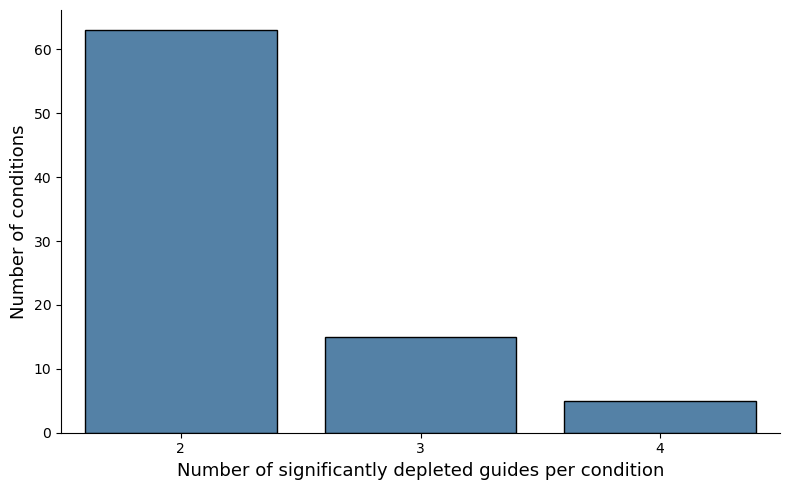

In [29]:
# Figure 2B

plt.close("all")
plt.figure(figsize=(8, 5))
sns.countplot(x="n_guide_support", data=agg_df, color="steelblue", edgecolor="black")
plt.xlabel("Number of significantly depleted guides per condition", fontsize=13)
plt.ylabel("Number of conditions", fontsize=13)
sns.despine()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fisher_number_depl_guide_{cell_type_col}.pdf", format="pdf", dpi=300)
plt.show()

/tmp/ipykernel_845178/1733968037.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(


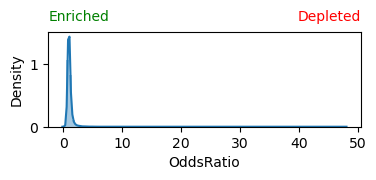

In [30]:
# Figure S5 A

plt.close("all")
fig, ax = plt.subplots(figsize=(4, 2))
sns.distplot(
    fisher_results_per_guide[fisher_results_per_guide["observed_control_in_T (d)"] > 5]["odds_ratio"],
    bins=100,
    kde=True,
    ax=ax
)
ax.set_xlabel("OddsRatio")

# Add text for "Enriched" on the left and "Depleted" on the right
ymin, ymax = ax.get_ylim()
xmin, xmax = ax.get_xlim()
# Place "Enriched" on far left, "Depleted" on far right, vertically centered
ax.text(xmin, (ymax-ymin)*0.5 + 1, "Enriched", va="center", ha="left", fontsize=10, color="green")
ax.text(xmax, (ymax-ymin)*0.5 + 1, "Depleted", va="center", ha="right", fontsize=10, color="red")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/log_odds_ratio_{cell_type_col}.pdf", dpi=300, format="pdf")
plt.show()

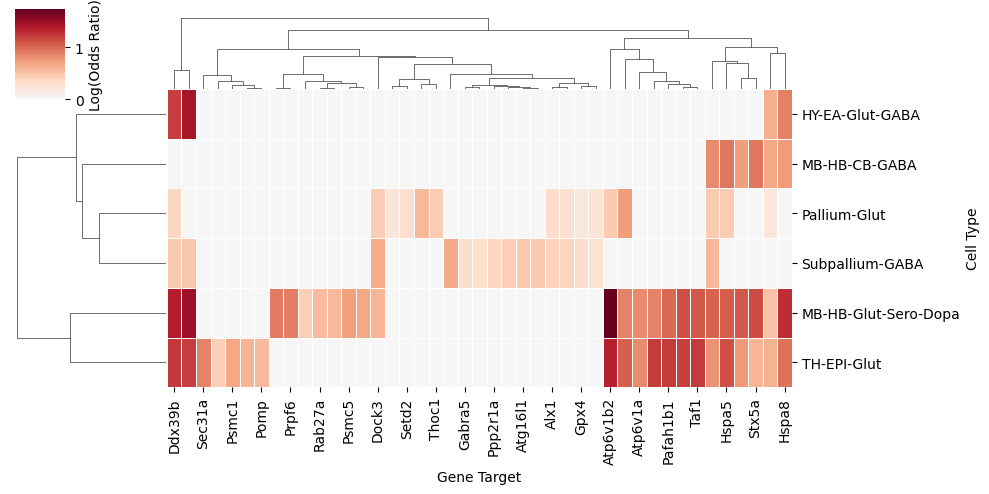

In [31]:
# Figure 2 A

plt.close("all")
agg_df["log_odds_ratio"] = np.log(agg_df["odds_ratio"])
pivot_df = agg_df.pivot(index='cell_type', columns='gene_target', values='log_odds_ratio')

top_genes = list(agg_df["gene_target"].unique())
filtered_pivot = pivot_df[top_genes].fillna(0)

# Transpose for heatmap: now genes are on y-axis, cell types on x-axis
filtered_pivot_T = filtered_pivot #.transpose()

# create clustermap and get figure and colorbar axis
g = sns.clustermap(
    filtered_pivot_T,
    cmap="RdBu_r",  # Red for enrichment, Blue for depletion (Fitness Loss)
    center=0,
    annot=False,
    cbar_kws={'label': 'Log(Odds Ratio)'},
    linewidths=.5,
    figsize=(10, 5),
    method="weighted"
)


g.ax_heatmap.set_xlabel("Gene Target")
g.ax_heatmap.set_ylabel("Cell Type")

plt.savefig(f"{FIG_DIR}/fisher_fitness_loss_heatmap_log_{cell_type_col}_transposed.pdf", format="pdf", dpi=300)
plt.show()

In [32]:
conditions_to_plot = agg_df.sort_values("odds_ratio", ascending=False).head(10)["condition"].tolist()

# Filter fisher_results_per_guide for these conditions
selected_guides = fisher_results_per_guide[
    fisher_results_per_guide["condition"].isin(conditions_to_plot)
]

data = {
    'Gene': selected_guides['gene_target'],
    'Guide': selected_guides['target_guide'].str.split("_").str[-1].apply(lambda x: f"G{x}"),
    'Odds_Ratio': selected_guides['odds_ratio'],
    'Cell_Type': selected_guides["cell_type"]
}
df_plot = pd.DataFrame(data)
df_plot["Condition"] = df_plot["Gene"] + " in \n" + df_plot["Cell_Type"]

/tmp/ipykernel_845178/2435807516.py:14: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(data=df_plot, x='log_odds_ratio', y='Condition',


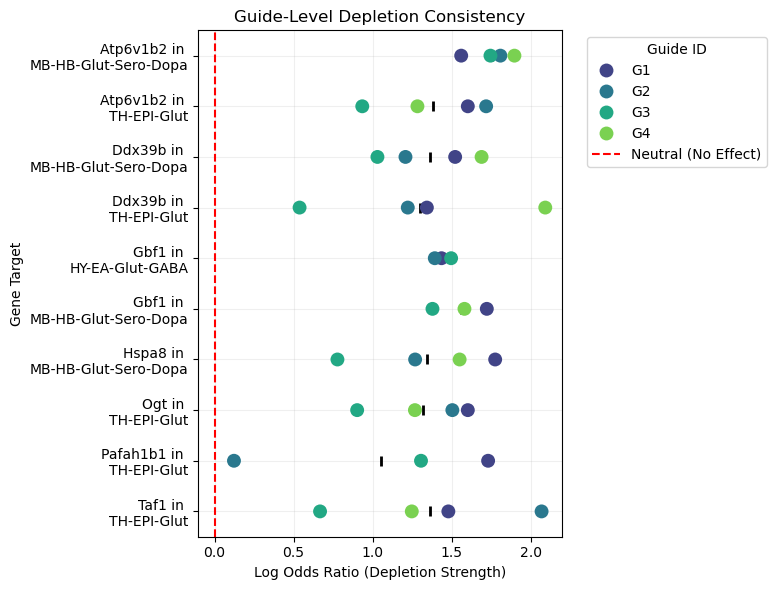

In [33]:
# Figure 2 C

plt.close("all")

df_plot["log_odds_ratio"] = np.log(df_plot["Odds_Ratio"])

plt.figure(figsize=(8, 6))

# 1. Plot individual guide points
sns.stripplot(data=df_plot, x='log_odds_ratio', y='Condition', 
              hue='Guide', palette='viridis', size=10, jitter=False)

# 2. Add a pointplot to show the mean/consistency line
sns.pointplot(data=df_plot, x='log_odds_ratio', y='Condition', 
              color='black', markers='|', join=False, errorbar=None)

# 3. Add the "Neutral" vertical line
plt.axvline(x=0, color='red', linestyle='--', label='Neutral (No Effect)')

#plt.xscale('log') # Use log scale for Odds Ratios to show magnitude clearly
plt.title('Guide-Level Depletion Consistency')
plt.xlabel('Log Odds Ratio (Depletion Strength)')
plt.ylabel('Gene Target')
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend(title='Guide ID', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/guide_consistency_{cell_type_col}.pdf", dpi=300, format="pdf")
plt.show()

### MAGECK test

In [48]:
cell_type_col = "neighborhood"

In [49]:
_, fisher_table_per_guide  = compute_fisher_results_per_gene(
    all_obs, 
    ngs_counts, 
    cell_type_col=cell_type_col,
    min_cells_per_guide=0
    )

/tmp/ipykernel_1780373/3622398870.py:60: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  observed_counts = adata_obs.groupby(['target_guide', cell_type_col]).size().unstack(fill_value=0)


In [ ]:
OUT_DIR = f"{BASE_DIR}/analysis/cell_type_proportions_analysis/mageck/{cell_type_col}"
os.makedirs(OUT_DIR, exist_ok=True)

In [52]:
def prepare_mageck_input(fisher_table_per_guide, adata, cell_type_col, OUT_DIR):
    """
    Prepares input files per cell type for MAGECK analysis.

    Parameters:
    - fisher_table_per_guide: DataFrame with per-guide Fisher test results.
    - adata: AnnData object with .obs containing cell annotations.
    - cell_type_col: column name in adata.obs specifying cell type.
    - OUT_DIR: output directory for MAGECK input and results.
    """
    import os

    all_cell_types = adata.obs[cell_type_col].unique() 
    fisher_table_per_guide["condition"] = fisher_table_per_guide["gene_target"] + "_" + fisher_table_per_guide["cell_type"]
    mageck_input = fisher_table_per_guide[
        ["target_guide", "gene_target", "cell_type", "expected_pert_in_T (a)", "observed_pert_in_T (b)"]
    ]
    mageck_input = mageck_input.copy()
    mageck_input["expected_pert_in_T (a)"] = mageck_input["expected_pert_in_T (a)"].astype(int)
    mageck_input.rename(
        columns={
            "target_guide": "sgRNA", 
            "gene_target": "gene",  
            "expected_pert_in_T (a)": "expected", 
            "observed_pert_in_T (b)": "observed"
        }, 
        inplace=True
    )

    os.makedirs(f"{OUT_DIR}/mageck_input", exist_ok=True)
    os.makedirs(f"{OUT_DIR}/mageck_results", exist_ok=True)

    for cell_type in all_cell_types:
        cell_type_id = str(cell_type).split(" ")[0]
        os.makedirs(f"{OUT_DIR}/mageck_results/{cell_type_id}", exist_ok=True)
        mageck_input_cell_type = mageck_input[mageck_input["cell_type"].str.contains(str(cell_type))]
        mageck_input_cell_type = mageck_input_cell_type.drop(columns=["cell_type"])
        mageck_input_cell_type.to_csv(f"{OUT_DIR}/mageck_input/{cell_type_id}.txt", sep="\t", index=False)


prepare_mageck_input(fisher_table_per_guide, adata, cell_type_col, OUT_DIR)

Next we need to run MAGeCK:

In [54]:
!bash scripts/run_mageck.sh "{OUT_DIR}"

Running MAGeCK2 test for cell Pallium-Glut ...
INFO  @ Tue, 10 Mar 2026 19:40:49: Parameters: /workspace/mageck2/bin/mageck2 test -k /data/perturbai/WB8588_screen//analysis/cell_type_proportions_analysis/mageck/neighborhood/mageck_input/Pallium-Glut.txt -t observed -c expected -n /data/perturbai/WB8588_screen//analysis/cell_type_proportions_analysis/mageck/neighborhood/mageck_results/Pallium-Glut/mageck_results 
INFO  @ Tue, 10 Mar 2026 19:40:49: Welcome to MAGeCK2 v0.1.0. Command: test 
INFO  @ Tue, 10 Mar 2026 19:40:49: Loading count table from /data/perturbai/WB8588_screen//analysis/cell_type_proportions_analysis/mageck/neighborhood/mageck_input/Pallium-Glut.txt  
INFO  @ Tue, 10 Mar 2026 19:40:49: Processing 1 lines.. 
WARNING @ Tue, 10 Mar 2026 19:40:49: Duplicated sgRNA IDs: Abat_1 in line 3. Skip this record. 
WARNING @ Tue, 10 Mar 2026 19:40:49: Duplicated sgRNA IDs: Abat_2 in line 5. Skip this record. 
WARNING @ Tue, 10 Mar 2026 19:40:49: Duplicated sgRNA IDs: Abat_3 in line 7

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



INFO  @ Tue, 10 Mar 2026 19:40:52: Command message: 
INFO  @ Tue, 10 Mar 2026 19:40:52:   Welcome to RRA v 0.5.9. 
INFO  @ Tue, 10 Mar 2026 19:40:52:   Skipping gene NA for permutation ... 
INFO  @ Tue, 10 Mar 2026 19:40:52:   Skipping gene na for permutation ... 
INFO  @ Tue, 10 Mar 2026 19:40:52:   Reading input file... 
INFO  @ Tue, 10 Mar 2026 19:40:52:   Summary: 8183 sgRNAs, 1948 genes, 1 lists; skipped sgRNAs:0 
INFO  @ Tue, 10 Mar 2026 19:40:52:   Computing lo-values for each group... 
INFO  @ Tue, 10 Mar 2026 19:40:52:   Computing false discovery rate... 
INFO  @ Tue, 10 Mar 2026 19:40:52:   Permuting genes with 3 sgRNAs... 
INFO  @ Tue, 10 Mar 2026 19:40:52:   Permuting genes with 4 sgRNAs... 
INFO  @ Tue, 10 Mar 2026 19:40:52:   Number of genes under FDR adjustment: 1948 
INFO  @ Tue, 10 Mar 2026 19:40:52:   Saving to output file... 
INFO  @ Tue, 10 Mar 2026 19:40:52:   RRA completed. 
INFO  @ Tue, 10 Mar 2026 19:40:52:   Groups deletion complete. 
INFO  @ Tue, 10 Mar 2026 1

In [55]:
all_mageck_results = []
all_mageck_results_guide = []

all_cell_types = adata.obs[cell_type_col].unique()

for cell_type in all_cell_types:
    cell_type_id = cell_type.split(" ")[0]
    if os.path.exists(f"{OUT_DIR}/mageck_results/{cell_type_id}/mageck_results.gene_summary.txt"):
        mageck_results_gene = pd.read_csv(f"{OUT_DIR}/mageck_results/{cell_type_id}/mageck_results.gene_summary.txt", sep="\t")
        mageck_results_gene["cell_type"] = cell_type
        all_mageck_results.append(mageck_results_gene)
        mageck_results_guide = pd.read_csv(f"{OUT_DIR}/mageck_results/{cell_type_id}/mageck_results.sgrna_summary.txt", sep="\t")
        mageck_results_guide["cell_type"] = cell_type
        all_mageck_results_guide.append(mageck_results_guide)
all_mageck_results = pd.concat(all_mageck_results)
all_mageck_results_guide = pd.concat(all_mageck_results_guide)

We don't expect to have any significantly enriched hits:

In [56]:
all_mageck_results[all_mageck_results["pos|fdr"] < 0.05]

,id,num,neg|score,neg|p-value,neg|fdr,neg|rank,neg|goodsgrna,neg|lfc,pos|score,pos|p-value,pos|fdr,pos|rank,pos|goodsgrna,pos|lfc,cell_type


In [57]:
mageck_sig = all_mageck_results[
    (all_mageck_results["neg|fdr"] < 0.05) & 
    (all_mageck_results["neg|lfc"].abs() > 0.25) & 
    (all_mageck_results["id"] != "Safe_target")
    ]

In [58]:
# mageck_results_neighborhood tab of Data S3

mageck_sig.to_csv(f"{OUT_DIR}/mageck_sig_{cell_type_col}.csv", sep=",", index=False)

/tmp/ipykernel_1780373/601744187.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(


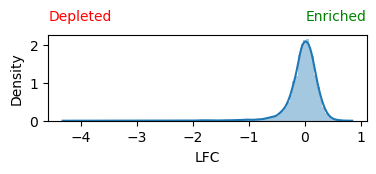

In [ ]:
# Figure 2 B

plt.close("all")
fig, ax = plt.subplots(figsize=(4, 2))
sns.distplot(
    all_mageck_results["neg|lfc"],
    bins=100,
    kde=True,
    ax=ax
)
ax.set_xlabel("LFC")

# Add text for "Enriched" on the left and "Depleted" on the right
ymin, ymax = ax.get_ylim()
xmin, xmax = ax.get_xlim()
# Place "Enriched" on far left, "Depleted" on far right, vertically centered
ax.text(xmin, (ymax-ymin) + 0.5, "Depleted", va="center", ha="left", fontsize=10, color="red")
ax.text(xmax, (ymax-ymin) + 0.5, "Enriched", va="center", ha="right", fontsize=10, color="green")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/mageck_lfc_{cell_type_col}.pdf", dpi=300, format="pdf")
plt.show()

In [61]:
all_mageck_results_guide["condition"] = all_mageck_results_guide["Gene"] + "_" + all_mageck_results_guide["cell_type"]

In [64]:
mageck_sig["condition"] = mageck_sig["id"] + "_" + mageck_sig["cell_type"]

/tmp/ipykernel_1780373/301097767.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mageck_sig["condition"] = mageck_sig["id"] + "_" + mageck_sig["cell_type"]


In [ ]:
conditions_to_plot = mageck_sig.sort_values("neg|lfc", ascending=True).head(10)["condition"].tolist()

selected_guides = all_mageck_results_guide[
    all_mageck_results_guide["condition"].isin(conditions_to_plot)
]

data = {
    'Gene': selected_guides['Gene'],
    'Guide': selected_guides['sgrna'].str.split("_").str[-1].apply(lambda x: f"sgRNA{x}"),
    'LFC': selected_guides['LFC'],
    'Cell_Type': selected_guides["cell_type"]
}
df_plot = pd.DataFrame(data)
df_plot["Condition"] = df_plot["Gene"] + " in \n" + df_plot["Cell_Type"]

/tmp/ipykernel_1780373/2061487328.py:16: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(data=df_plot, x='LFC', y='Condition',


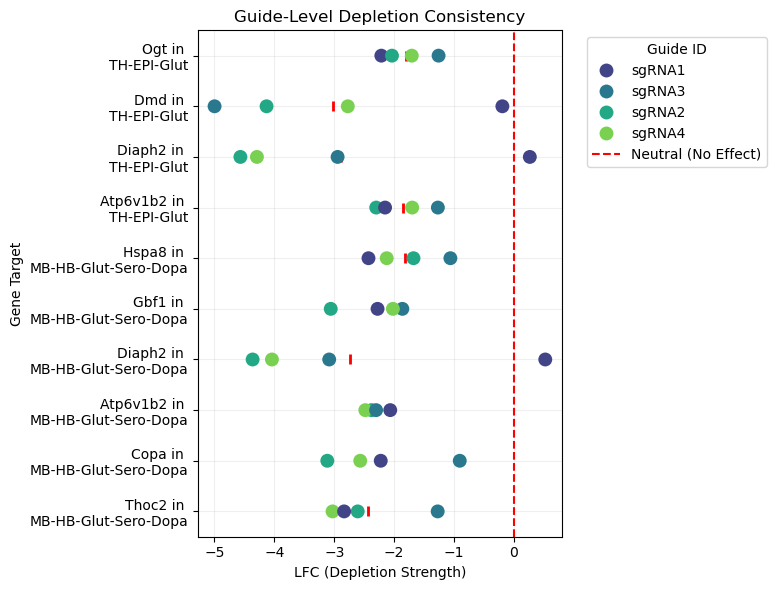

In [ ]:
# Figure S5 C

plt.close("all")

plt.figure(figsize=(8, 6))

sns.stripplot(data=df_plot, x='LFC', y='Condition', 
              hue='Guide', palette='viridis', size=10, jitter=False)

sns.pointplot(data=df_plot, x='LFC', y='Condition', 
              color='red', markers='|', join=False, errorbar=None)

plt.axvline(x=0, color='red', linestyle='--', label='Neutral (No Effect)')

plt.title('Guide-Level Depletion Consistency')
plt.xlabel('LFC (Depletion Strength)')
plt.ylabel('Gene Target')
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend(title='Guide ID', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/mageck_guide_consistency_{cell_type_col}.pdf", dpi=300, format="pdf")
plt.show()

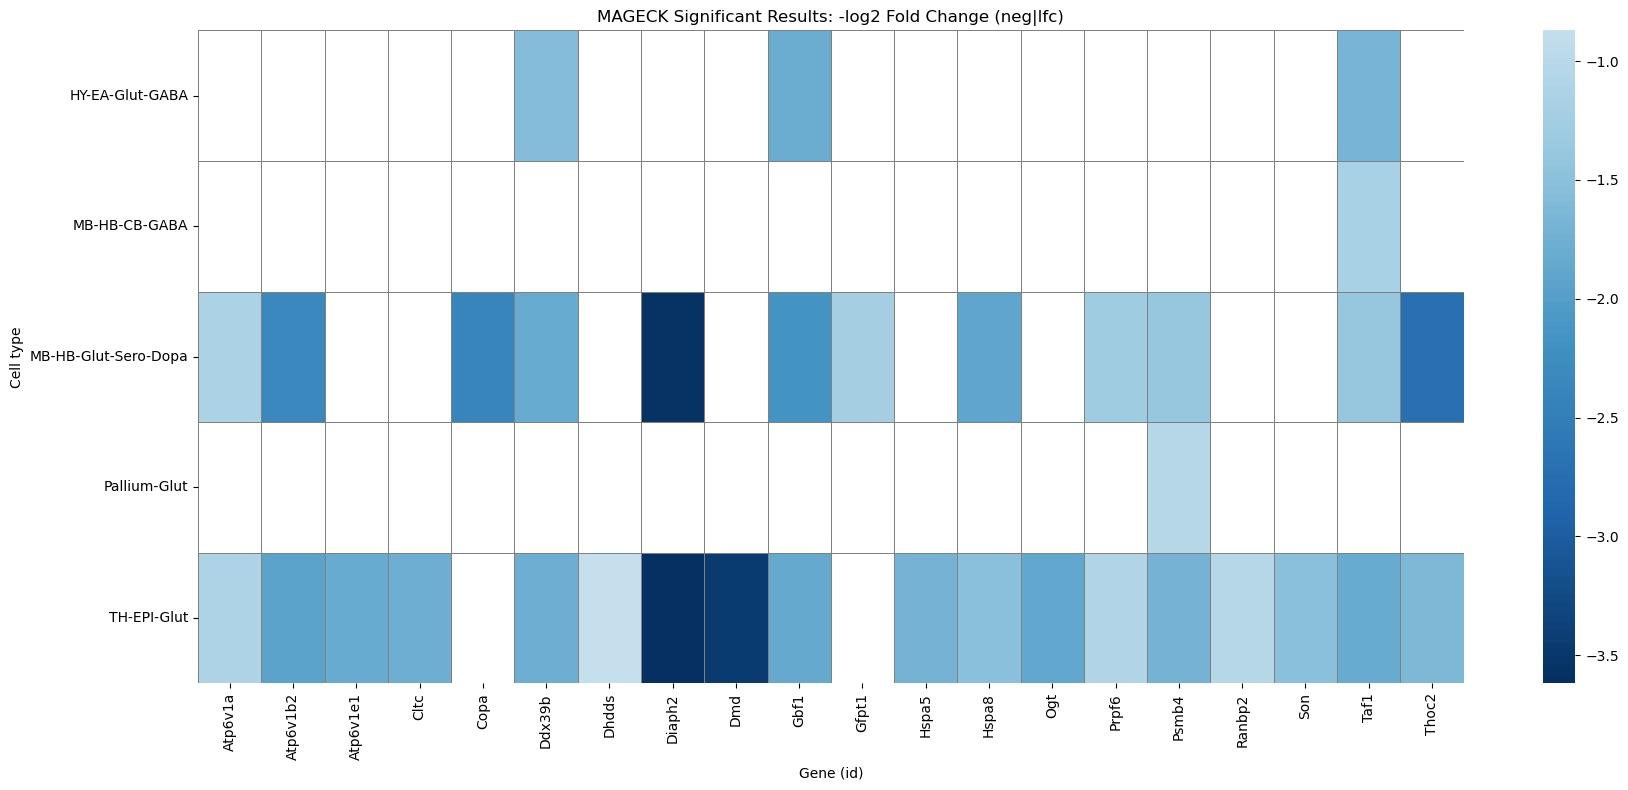

In [ ]:
# Figure S5 B

plt.close("all")
heatmap_data = mageck_sig.pivot(index="cell_type", columns="id", values="neg|lfc")

plt.figure(figsize=(18, 8))
sns.heatmap(heatmap_data, cmap="RdBu_r", center=0, linewidths=0.5, linecolor='grey')
plt.title("MAGECK Significant Results: -log2 Fold Change (neg|lfc)")
plt.xlabel("Gene (id)")
plt.ylabel("Cell type")
plt.tight_layout()
plt.savefig("{FIG_DIR}/mageck_heatmap_{cell_type_col}.pdf", dpi=300, format="pdf")
plt.show()